In [ ]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import json
from collections import defaultdict
import scienceplots

from helper_functions import boxplot_formatted

In [2]:
DARK_BLUE  = (0.0, 0.4667, 0.7333)
LIGHT_BLUE = (0.2, 0.7333, 0.9333)
GREEN      = (0.0, 0.6, 0.5333)
ORANGE     = (0.9333, 0.4667, 0.2)
RED        = (0.8, 0.2, 0.0667)
PINK       = (0.9333, 0.2, 0.4667)
GRAY       = (0.7333, 0.7333, 0.7333)

SAVE = False

In [3]:
N_TRIALS = 80
T_INIT = 300
DT = 0.1
DT_RECORD = 10
N_NEURONS = 400

def load_data(folder):
    data = {}
    for trial in range(N_TRIALS):
        data[trial] = {}
        
        for file in os.listdir(folder):
            file_name = os.path.join(folder, file)
            
            if f"_{trial}_initial_weights.csv" in file:
                loaded_data = np.genfromtxt(file_name, delimiter=',', names=True, dtype=None, encoding='utf-8')
                N = loaded_data['post'].max()+1
                W = np.zeros((N, N), dtype=float)
                for pre, post, w in loaded_data:
                    W[pre, post] = w
                data[trial]['ws_init'] = W
                data[trial]['ws_init_list'] = loaded_data
                
            if f"_{trial}_final_weights.csv" in file:
                loaded_data = np.genfromtxt(file_name, delimiter=',', names=True, dtype=None, encoding='utf-8')
                N = loaded_data['post'].max()+1
                W = np.zeros((N, N), dtype=float)
                for pre, post, w in loaded_data:
                    W[pre, post] = w
                data[trial]['ws_final'] = W
                data[trial]['ws_final_list'] = loaded_data
                
            if f"_{trial}_neuron_ids" in file:
                with open(file_name, "r") as f:
                    neuron_ids = json.load(f)
                    data[trial]['ids'] = neuron_ids
                    
            if f"_{trial}_results.csv" in file:
                with open(file_name, "r") as f:
                    results = np.loadtxt(f)
                    data[trial]['s_acc'] = np.mean(results[:50])
                    data[trial]['e_acc'] = np.mean(results[-50:])
                    
    return data

In [4]:
folder_fb = '/Users/juliuswuerzler/Desktop/Results_Thesis/Delta_BCM_Update/FB/02_23_22_49_LR_1_PW_04_HigherDeltaBCM_30_17_15_4'
folder_nfb = '/Users/juliuswuerzler/Desktop/Results_Thesis/NoFb'
data = {}
data_nfb = {}

data = load_data(folder_fb)
data_nfb = load_data(folder_nfb)

In [5]:
def collect_weights(data, n_trials, mask_fn=None):
    start, end = [], []
    for i in range(n_trials):
        mask = mask_fn(data[i]) if mask_fn else slice(None)
        start.append(data[i]['ws_init_list']['w'][mask])
        end.append(data[i]['ws_final_list']['w'][mask])
    return np.concatenate(start), np.concatenate(end)

def stim_mask(trial):
    stim_ids = trial['ids']['stimulation_ids']
    return np.isin(trial['ws_init_list']['pre'], stim_ids) | np.isin(trial['ws_init_list']['post'], stim_ids)

all_start_weights,      all_end_weights      = collect_weights(data, N_TRIALS)
stim_start_weights,     stim_end_weights     = collect_weights(data, N_TRIALS, stim_mask)
not_stim_start_weights, not_stim_end_weights = collect_weights(data, N_TRIALS, lambda t: ~stim_mask(t))
all_start_weights_nfb,      all_end_weights_nfb      = collect_weights(data_nfb, N_TRIALS)
stim_start_weights_nfb,     stim_end_weights_nfb     = collect_weights(data_nfb, N_TRIALS, stim_mask)
not_stim_start_weights_nfb, not_stim_end_weights_nfb = collect_weights(data_nfb, N_TRIALS, lambda t: ~stim_mask(t))

In [6]:
incoming_weights_per_neuron = np.zeros((N_TRIALS, N_NEURONS))
incoming_weights_per_neuron_nfb = np.zeros_like(incoming_weights_per_neuron)
incoming_weights_per_neuron_init = np.zeros_like(incoming_weights_per_neuron)
incoming_weights_per_neuron_init_nofb = np.zeros_like(incoming_weights_per_neuron)

SPARSITY_THRESHOLD = 0.02
sparsity = np.zeros(N_TRIALS)
sparsity_nfb = np.zeros_like(sparsity)
sparsity_stim = np.zeros_like(sparsity)
sparsity_nstim = np.zeros_like(sparsity)

for i in range(N_TRIALS):
    for n in range(N_NEURONS):
        incoming_weights_per_neuron[i,n] = data[i]['ws_final'][:, n].sum()
        incoming_weights_per_neuron_nfb[i,n] = data_nfb[i]['ws_final'][:, n].sum()
        
        incoming_weights_per_neuron_init[i,n] = data[i]['ws_init'][n, :].sum()
        incoming_weights_per_neuron_init_nofb[i,n] = data_nfb[i]['ws_init'][n, :].sum()
        
    sparsity[i] = (data[i]['ws_final_list']['w'] < SPARSITY_THRESHOLD).mean()
    sparsity_nfb[i] = (data_nfb[i]['ws_final_list']['w'] < SPARSITY_THRESHOLD).mean()
    
    stim_ids = data[i]['ids']['stimulation_ids']
    pre_mask = np.isin(data[i]['ws_init_list']['pre'], stim_ids)
    post_mask = np.isin(data[i]['ws_init_list']['post'], stim_ids)
    sparsity_stim[i] = (data[i]['ws_final_list']['w'][:][pre_mask | post_mask] < SPARSITY_THRESHOLD).mean()
    sparsity_nstim[i] = (data[i]['ws_final_list']['w'][:][~(pre_mask | post_mask)] < SPARSITY_THRESHOLD).mean()

In [7]:
def hist_with_edge(ax, data, bins, label, color, density):
    ax.hist(data, bins, alpha=0.25, label=label, color=color, density=density)
    ax.hist(data, bins, alpha=1, color=color, density=density, histtype='step', linewidth=1)

In [8]:
def boxplot_formatted(ax, data, colors, labels, **boxplot_kwargs):
    bp = ax.boxplot(
        data, 
        widths=0.3,
        patch_artist=True,
        **boxplot_kwargs
    )
    for box, color in zip(bp['boxes'], colors):
        box.set_facecolor(color)
        
    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(1.5)

    for whisker in bp['whiskers']:
        whisker.set_color('black')

    for cap in bp['caps']:
        cap.set_color('black')
        
    ax.set_xticks(np.arange(len(colors))+1)
    ax.set_xticklabels(labels)

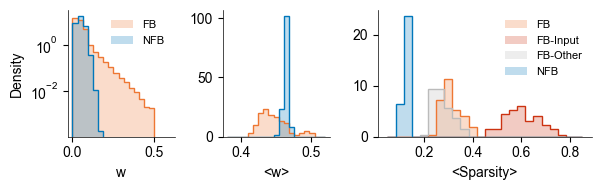

In [9]:
plt.style.use(['nature_d'])

fig, axs = plt.subplot_mosaic([["EndAll","EndMean", "Sparsity"]], sharey=False, width_ratios=[1,1,2])

# All weights
bins = np.linspace(0, 0.6, 20)
hist_with_edge(axs["EndAll"], all_end_weights, bins, "FB", ORANGE, True)
hist_with_edge(axs["EndAll"], all_end_weights_nfb, bins, "NFB", DARK_BLUE, True)
axs["EndAll"].set_yscale('log')
axs["EndAll"].set_ylabel("Density")
axs["EndAll"].set_xlabel("w")
axs["EndAll"].legend()

# mean weight per network
bins = np.linspace(0.38, 0.52, 20)
hist_with_edge(axs["EndMean"], incoming_weights_per_neuron.mean(axis=1), bins, "FB", ORANGE, True)
hist_with_edge(axs["EndMean"], incoming_weights_per_neuron_nfb.mean(axis=1), bins, "NFB", DARK_BLUE, True)
axs["EndMean"].set_xlabel("<w>")

# Sparsity
bins = np.linspace(0.05, 0.85, 25)
hist_with_edge(axs["Sparsity"], sparsity, bins, "FB", ORANGE, True)
hist_with_edge(axs["Sparsity"], sparsity_stim, bins, "FB-Input", RED, True)
hist_with_edge(axs["Sparsity"], sparsity_nstim, bins, "FB-Other", GRAY, True)
hist_with_edge(axs["Sparsity"], sparsity_nfb, bins, "NFB", DARK_BLUE, True)

# hist_with_edge(axs["Sparsity"], sparsity_nstim, bins, "FB:Rest", GRAY, True)
axs["Sparsity"].set_xlabel("<Sparsity>")
axs["Sparsity"].legend()

w, h = fig.get_size_inches()
fig.set_size_inches(w, 2)

fig.tight_layout()
if SAVE:
    fig.savefig("fig_2_wChange.pdf", dpi=300)
    
plt.show()

In [10]:
from scipy.stats import mannwhitneyu

def mann_whitney_report(x, y, alternative="two-sided", alpha=0.05):
    """
    Perform Mann–Whitney U test and print a formatted statistical report.
    """

    x = np.asarray(x)
    y = np.asarray(y)

    n1 = len(x)
    n2 = len(y)

    # Descriptive statistics
    median_x = np.median(x)
    median_y = np.median(y)

    iqr_x = np.percentile(x, 75) - np.percentile(x, 25)
    iqr_y = np.percentile(y, 75) - np.percentile(y, 25)

    # Test
    res = mannwhitneyu(x, y, alternative=alternative)
    U = res.statistic
    p = res.pvalue

    # Effect sizes
    rank_biserial = 1 - (2 * U) / (n1 * n2)
    prob_superiority = U / (n1 * n2)

    # Print report
    print("Mann–Whitney U Test Report")
    print("-" * 40)
    print(f"Sample sizes: n1 = {n1}, n2 = {n2}")
    print()
    print("Descriptive statistics:")
    print(f"  Group 1: median = {median_x:.4f}, IQR = {iqr_x:.4f}")
    print(f"  Group 2: median = {median_y:.4f}, IQR = {iqr_y:.4f}")
    print()
    print("Test results:")
    print(f"  U statistic = {U:.4f}")
    print(f"  p-value     = {p}")
    print(f"  Rank-biserial correlation (effect size) = {rank_biserial:.4f}")
    print(f"  Probability of superiority              = {prob_superiority:.4f}")
    print()
    
    if p < alpha:
        print(f"Result: Significant difference (p < {alpha})")
    else:
        print(f"Result: No significant difference (p ≥ {alpha})")


In [11]:
mann_whitney_report(incoming_weights_per_neuron.mean(axis=1), incoming_weights_per_neuron_nfb.mean(axis=1))

Mann–Whitney U Test Report
----------------------------------------
Sample sizes: n1 = 80, n2 = 80

Descriptive statistics:
  Group 1: median = 0.4422, IQR = 0.0247
  Group 2: median = 0.4638, IQR = 0.0036

Test results:
  U statistic = 1128.0000
  p-value     = 1.55786171390723e-12
  Rank-biserial correlation (effect size) = 0.6475
  Probability of superiority              = 0.1762

Result: Significant difference (p < 0.05)


In [12]:
mann_whitney_report(sparsity, sparsity_nfb)

Mann–Whitney U Test Report
----------------------------------------
Sample sizes: n1 = 80, n2 = 80

Descriptive statistics:
  Group 1: median = 0.2988, IQR = 0.0566
  Group 2: median = 0.1210, IQR = 0.0064

Test results:
  U statistic = 6400.0000
  p-value     = 9.338017380644485e-28
  Rank-biserial correlation (effect size) = -1.0000
  Probability of superiority              = 1.0000

Result: Significant difference (p < 0.05)


In [13]:
from scipy import stats

def paired_ttest_report(x, y, alpha=0.05, alternative="two-sided"):
    """
    Perform paired t-test and print a formatted statistical report.

    Parameters
    ----------
    x : array-like
        First condition (e.g., random pruning degradation)
    y : array-like
        Second condition (e.g., selective pruning degradation)
    alpha : float
        Significance level (default = 0.05)
    alternative : {"two-sided", "greater", "less"}
        Alternative hypothesis for scipy ttest_rel
    """

    x = np.asarray(x)
    y = np.asarray(y)

    if len(x) != len(y):
        raise ValueError("Samples must have the same length (paired design).")

    n = len(x)
    df = n - 1

    # Descriptive statistics
    mean_x = np.mean(x)
    mean_y = np.mean(y)
    sd_x = np.std(x, ddof=1)
    sd_y = np.std(y, ddof=1)

    # Paired differences
    diff = y - x
    mean_diff = np.mean(diff)
    sd_diff = np.std(diff, ddof=1)

    # Paired t-test
    res = stats.ttest_rel(y, x, alternative=alternative)
    t_stat = res.statistic
    p_value = res.pvalue

    # Confidence interval for mean difference
    se_diff = sd_diff / np.sqrt(n)
    t_crit = stats.t.ppf(1 - alpha/2, df)
    ci_low = mean_diff - t_crit * se_diff
    ci_high = mean_diff + t_crit * se_diff

    # Effect sizes
    cohens_d = mean_diff / sd_diff  # Cohen's dz (paired)
    
    # Hedges g correction for small samples
    correction = 1 - (3 / (4*df - 1)) if df > 1 else 1
    hedges_g = cohens_d * correction

    # Print report
    print("Paired t-Test Report")
    print("-" * 50)
    print(f"Sample size: n = {n}")
    print(f"Degrees of freedom: df = {df}")
    print()
    print("Descriptive statistics:")
    print(f"  Condition 1: mean = {mean_x:.6f}, SD = {sd_x:.6f}")
    print(f"  Condition 2: mean = {mean_y:.6f}, SD = {sd_y:.6f}")
    print()
    print("Paired difference (Condition 2 - Condition 1):")
    print(f"  Mean difference = {mean_diff:.6f}")
    print(f"  SD of diff      = {sd_diff:.6f}")
    print(f"  95% CI          = [{ci_low:.6f}, {ci_high:.6f}]")
    print()
    print("Test results:")
    print(f"  t({df}) = {t_stat:.6f}")
    print(f"  p-value = {p_value:.8f}")
    print()
    print("Effect sizes:")
    print(f"  Cohen's d (paired, dz) = {cohens_d:.6f}")
    print(f"  Hedges' g              = {hedges_g:.6f}")
    print()

    if p_value < alpha:
        print(f"Result: Significant difference (p < {alpha})")
    else:
        print(f"Result: No significant difference (p ≥ {alpha})")

In [14]:
# paired_ttest_report(data_dropout[0], data_dropout[1])

In [15]:
# paired_ttest_report(data_dropout[2], data_dropout[1])

In [27]:
K_PER_ELECTRODE = 3
N_ELECTRODES = 8
N=400
N_ORDERS = 3
stim_regions = [x for x in range(N_ELECTRODES)]
post_regions = ["U", "D", "R"]
phases = ["init", "final"]


for i in range(N_TRIALS):
    d = data[i]
    d['plot_data'] = {}
    
    # pre_ids = d['ws_init']['pre']
    # post_ids = d['ws_init']['post']
    
    for stim_region in stim_regions:
        d['plot_data'][stim_region] = {}
        
        for post_region in post_regions:
            d['plot_data'][stim_region][post_region] = {}
            
            pre_mask = d['ids']['stimulation_ids'][stim_region*K_PER_ELECTRODE:(stim_region+1)*K_PER_ELECTRODE]#np.isin(pre_ids, d['ids']['stimulation_ids'][stim_region*K_PER_ELECTRODE:(stim_region+1)*K_PER_ELECTRODE])

            post_mask = np.array([])
            if post_region != "R":
                post_mask = d['ids'][f'motor_ids_{post_region}']
            else:
                post_mask = np.setdiff1d(np.arange(N), np.hstack((d['ids'][f'motor_ids_U'],  d['ids'][f'motor_ids_D'])))
            
            d['plot_data'][stim_region][post_region]['N_CONN'] = d['ws_final_list']['w'][
                np.isin(d['ws_final_list']['pre'], pre_mask) & np.isin(d['ws_final_list']['post'], post_mask)
            ].size
            
            # for phase in phases:
            #     d['plot_data'][stim_region][post_region][phase] = {}
                
            #     for o in range(N_ORDERS):
            #         x0 = np.zeros((N)
            #         x0[pre_mask] = 1
            #         ws = (np.linalg.matrix_power(d[f'ws_{phase}'], o+1)@x0)[:, post_mask].flatten()
            #         d['plot_data'][stim_region][post_region][phase][o] = ws[ws>0]
            
            for phase in phases:
                d['plot_data'][stim_region][post_region][phase] = {}

                W = d[f'ws_{phase}']          # shape (N, N)

                x = np.zeros((N, 1))
                x[pre_mask, 0] = 1.0          # pre_mask is a list/array of indices

                for o in range(N_ORDERS):
                    x = W.T @ x                 # 1st step (o=0), 2nd step (o=1), ...
                    ws = x[post_mask, 0]      # responses in the post set (1D)

                    # store however you like:
                    d['plot_data'][stim_region][post_region][phase][o] = ws[ws > 0]
                    
                    x[~np.isin(np.arange(N), post_mask), 0]
                

# collect data for correlation calculation
corr_datas = []
corr_data = np.zeros((N_TRIALS, N_ELECTRODES, 4))
for o in range(N_ORDERS):
    corr_data = np.zeros((N_TRIALS, N_ELECTRODES, 4))
    for j in range(N_TRIALS):
        for i in range(N_ELECTRODES):
            d = data[j]
            dp = d['plot_data']
            
            improvement = d['e_acc'] - d['s_acc']
            
            for k, post_region in enumerate(post_regions):
                w_change = dp[i][post_region]['final'][o] - dp[i][post_region]['init'][o]
                if w_change.size < 1:
                    w_change = np.zeros(1)
                
                corr_data[j][i][0] = improvement
                corr_data[j][i][k+1] = w_change.mean()
                # corr_data[j][i][k+1] = w_change.sum()
    corr_datas.append(corr_data)
corr_data = corr_datas[0]


corr_data_N = np.zeros((N_TRIALS, N_ELECTRODES, 3))

for j in range(N_TRIALS):
    for i in range(N_ELECTRODES):
        d = data[j]
        dp = d['plot_data']
        
        improvement = d['e_acc'] - d['s_acc']

        
        corr_data_N[j][i][0] = improvement
        corr_data_N[j][i][1] = d['plot_data'][i]["U"]['N_CONN']
        corr_data_N[j][i][2] = d['plot_data'][i]["D"]['N_CONN']

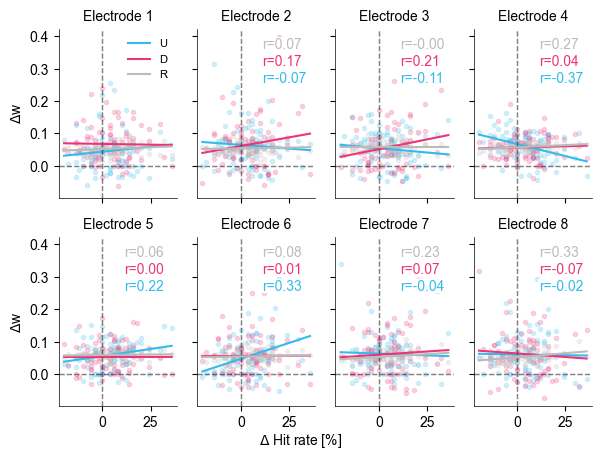

In [17]:
plt.style.use(['nature_d'])
fig, axs = plt.subplots(2, N_ELECTRODES // 2, sharex=True, sharey=True)

for i, ax in enumerate(axs.flatten()):
    
    for j, post_region in enumerate(post_regions):
        
        x = corr_data[:, i, 0] * 100
        y = corr_data[:, i, j+1]
        
        # Set color
        if post_region == "U":
            color = LIGHT_BLUE
        elif post_region == "D":
            color = PINK
        else:
            color = GRAY
            
        ax.axhline(0, color='black', linestyle='--', alpha=0.2)
        ax.axvline(0, color='black', linestyle='--', alpha=0.2)
        
        # Scatter
        ax.scatter(x, y, alpha=0.2, color=color)
        
        # Correlation
        r = np.corrcoef(x, y)[0, 1]
        
        ax.text(
            0.55, 0.75 + j * 0.1,
            f"r={r:.2f}",
            transform=ax.transAxes,
            verticalalignment='top',
            color=color,
            bbox=dict(facecolor="white", edgecolor="none", alpha=1.0, pad=0.2)
        )
        
        # ----- Regression line -----
        slope, intercept = np.polyfit(x, y, 1)
        x_fit = np.linspace(x.min(), x.max(), 100)
        y_fit = slope * x_fit + intercept
        ax.plot(x_fit, y_fit, color=color, linewidth=1.5, label=post_region)
        
        ax.set_title(f"Electrode {i+1}")


fig.text(0.5, 0.01, r'$\Delta$ Hit rate [%]', ha='center', va='center')
axs[0][0].set_ylabel(r'$\Delta$w')
axs[1][0].set_ylabel(r'$\Delta$w')
axs[0][0].legend(frameon=True, facecolor="white", framealpha=1.0, edgecolor="white")

w, h = fig.get_size_inches()
fig.set_size_inches(w, 4.5)

fig.tight_layout()
if SAVE:
    fig.savefig("fig_2_wChangeElectrodes.pdf", dpi=300)
plt.show()

In [18]:
# from scipy.stats import pearsonr

# plt.style.use(['nature_d'])

# fig, ax = plt.subplots(1,1)

# for i in range(N_ELECTRODES):
    
#     for j, (color, d, label) in enumerate(zip([RED, ORANGE, DARK_BLUE],
#                                        [corr_data[:,i, 1] - corr_data[:,i, 2],
#                                         corr_datas[1][:,i, 1] - corr_datas[1][:,i, 2],
#                                         corr_datas[2][:,i, 1] - corr_datas[2][:,i, 2]
#                                         ],
#                                        [r"$1^{\text{st}}$ order", r"$2^{\text{nd}}$ order", r"$3^{\text{rd}}$ order"])):
#         x = corr_data[:, i, 0]
#         y = d if i > 3 else - d
        
#         r, p = pearsonr(x, y)
        
#         # Optional significance stars
#         if p < 0.001:
#             sig = "***"
#         elif p < 0.01:
#             sig = "**"
#         elif p < 0.05:
#             sig = "*"
#         else:
#             sig = ""
            
#         ax.scatter(i + 1, r, color=color, marker='o', s=30, label=label if i==0 else "")
        
#         # Put significance stars next to the point
#         if sig:
#             ax.text(
#                 i + 1 + 0.08,   # small x-offset to the right
#                 r + 0.02*np.sign(r if r != 0 else 1),  # small y-offset (up for +r, down for -r)
#                 sig,
#                 ha="left",
#                 va="center",
#                 color="black",
#                 fontweight='bold'
#             )
    
# ax.axhline(0, color='black', linestyle='--', alpha=0.2)
# ax.set_xlabel('Electrode number')
# ax.set_ylabel('Correlation coeff.')
# ax.legend()

# plt.show()

In [19]:
# from scipy.stats import pearsonr

# plt.style.use(['nature_d'])
# fig, axs = plt.subplots(2, N_ELECTRODES // 2, sharex=True, sharey=True)

# for i, ax in enumerate(axs.flatten()):
    
#     for j, (color, d) in enumerate(zip([ORANGE],
#                                         [corr_data[:,i, 1] - corr_data[:,i, 2]])):
        
#         x = corr_data[:, -i-1, 0]
#         y = d if i < 4 else -d
#         ax.scatter(x, y, alpha=0.4, color=color)
        
#         # Correlation + significance
#         r, p = pearsonr(x, y)
        
#         # Optional significance stars
#         if p < 0.001:
#             sig = "***"
#         elif p < 0.01:
#             sig = "**"
#         elif p < 0.05:
#             sig = "*"
#         else:
#             sig = ""
        
#         ax.text(
#             0.5, 0.9 + j * 0.1,
#             f"r={r:.2f}{sig}",
#             transform=ax.transAxes,
#             verticalalignment='top',
#             color=color,
#             fontweight='bold' if sig != "" else 'normal'
#         )
        
#         ax.axhline(0, color='black', linestyle='--', alpha=0.2)
#         ax.axvline(0, color='black', linestyle='--', alpha=0.2)
        
#         # Regression line
#         slope, intercept = np.polyfit(x, y, 1)
#         x_fit = np.linspace(x.min(), x.max(), 100)
#         y_fit = slope * x_fit + intercept
#         ax.plot(x_fit, y_fit, color=color, linewidth=1.5)
        
#         ax.set_title(f"Electrode {i+1}")

# fig.text(0.5, 0.01, r'$\Delta$ hit rate [%]', ha='center', va='center')
# axs[0][0].set_ylabel(r'$\Delta w_U$ - $\Delta w_D$')
# axs[1][0].set_ylabel(r'$\Delta w_D$ - $\Delta w_U$')

# w, h = fig.get_size_inches()
# fig.set_size_inches(w, 4.5)


# fig.tight_layout()
# if SAVE:
#     fig.savefig("fig_2_wChangeElectrodeDiff.pdf", dpi=300)
# plt.show()

Electrode 1: r = -0.092, 95% CI [-0.306, 0.130], p = 0.416
Electrode 2: r = 0.177, 95% CI [-0.045, 0.382], p = 0.116
Electrode 3: r = 0.226, 95% CI [0.007, 0.425], p = 0.044
Electrode 4: r = 0.336, 95% CI [0.125, 0.517], p = 0.002
Electrode 5: r = 0.148, 95% CI [-0.074, 0.356], p = 0.190
Electrode 6: r = 0.229, 95% CI [0.009, 0.427], p = 0.041
Electrode 7: r = -0.076, 95% CI [-0.291, 0.146], p = 0.500
Electrode 8: r = 0.036, 95% CI [-0.185, 0.254], p = 0.748


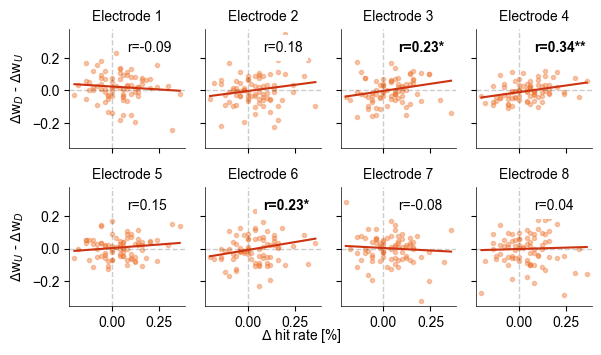

In [20]:
from scipy.stats import pearsonr, norm

plt.style.use(['nature_d'])
fig, axs = plt.subplots(2, N_ELECTRODES // 2, sharex=True, sharey=True)

for i, ax in enumerate(axs.flatten()):
    
    for j, (color, d) in enumerate(zip([ORANGE],
                                        [corr_data[:,i, 1] - corr_data[:,i, 2]])):
        
        x = corr_data[:, i, 0]
        y = -d if i < 4 else d
        ax.scatter(x, y, alpha=0.4, color=color)
        
        # --- Correlation ---
        r, p = pearsonr(x, y)
        n = len(x)
        
        # --- 95% CI using Fisher z transform ---
        z = np.arctanh(r)
        se = 1 / np.sqrt(n - 3)
        z_crit = norm.ppf(0.975)  # two-sided 95%
        z_low = z - z_crit * se
        z_high = z + z_crit * se
        r_low = np.tanh(z_low)
        r_high = np.tanh(z_high)
        
        # Format p-value properly
        if p < 0.001:
            p_text = "p < 0.001"
        else:
            p_text = f"p = {p:.3f}"
        
        # Print to console (for paper reporting)
        print(f"Electrode {i+1}: r = {r:.3f}, 95% CI [{r_low:.3f}, {r_high:.3f}], {p_text}")
        
        # Optional significance stars
        if p < 0.001:
            sig = "***"
        elif p < 0.01:
            sig = "**"
        elif p < 0.05:
            sig = "*"
        else:
            sig = ""
        
        
        # Annotate in plot
        ax.text(
            0.5, 0.9 + j * 0.1,
            f"r={r:.2f}{sig}",
            transform=ax.transAxes,
            verticalalignment='top',
            color='black',
            fontweight='bold' if sig != "" else 'normal',
            bbox=dict(
                facecolor='white',
                edgecolor='none',   # or 'black' if you want a border
                # boxstyle='round,pad=0.2'
            )
        )
        
        ax.axhline(0, color='black', linestyle='--', alpha=0.2)
        ax.axvline(0, color='black', linestyle='--', alpha=0.2)
        
        # Regression line
        slope, intercept = np.polyfit(x, y, 1)
        x_fit = np.linspace(x.min(), x.max(), 100)
        y_fit = slope * x_fit + intercept
        ax.plot(x_fit, y_fit, color=RED, linewidth=1.5)
        
        ax.set_title(f"Electrode {i+1}")

fig.text(0.5, 0.025, r'$\Delta$ hit rate [%]', ha='center', va='center')
axs[0][0].set_ylabel(r'$\Delta \text{w}_D$ - $\Delta \text{w}_U$')
axs[1][0].set_ylabel(r'$\Delta \text{w}_U$ - $\Delta \text{w}_D$')

w, h = fig.get_size_inches()
fig.set_size_inches(w, 3.5)

fig.tight_layout()
if True:
    fig.savefig("fig_2_wChangeElectrodeDiff.pdf", dpi=300)

plt.show()

Electrode 1: r = -0.151, 95% CI [-0.359, 0.071], p = 0.182
Electrode 2: r = -0.247, 95% CI [-0.443, -0.029], p = 0.027
Electrode 3: r = -0.004, 95% CI [-0.224, 0.215], p = 0.968
Electrode 4: r = 0.181, 95% CI [-0.041, 0.385], p = 0.108
Electrode 5: r = 0.040, 95% CI [-0.181, 0.258], p = 0.723
Electrode 6: r = 0.049, 95% CI [-0.173, 0.266], p = 0.668
Electrode 7: r = -0.120, 95% CI [-0.331, 0.103], p = 0.290
Electrode 8: r = -0.071, 95% CI [-0.286, 0.151], p = 0.533


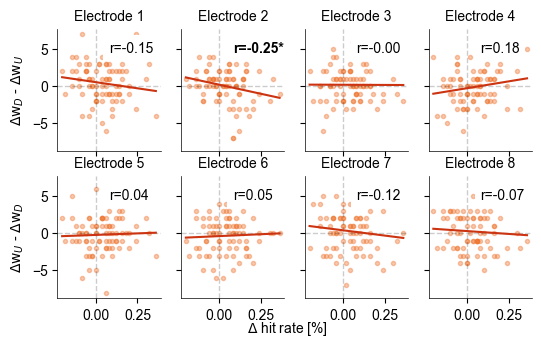

In [29]:
from scipy.stats import pearsonr, norm

plt.style.use(['nature_d'])
fig, axs = plt.subplots(2, N_ELECTRODES // 2, sharex=True, sharey=True)

for i, ax in enumerate(axs.flatten()):
    
    for j, (color, d) in enumerate(zip([ORANGE],
                                        [corr_data_N[:,i, 1] - corr_data_N[:,i, 2]])):
        
        x = corr_data[:, i, 0]
        y = -d if i < 4 else d
        ax.scatter(x, y, alpha=0.4, color=color)
        
        # --- Correlation ---
        r, p = pearsonr(x, y)
        n = len(x)
        
        # --- 95% CI using Fisher z transform ---
        z = np.arctanh(r)
        se = 1 / np.sqrt(n - 3)
        z_crit = norm.ppf(0.975)  # two-sided 95%
        z_low = z - z_crit * se
        z_high = z + z_crit * se
        r_low = np.tanh(z_low)
        r_high = np.tanh(z_high)
        
        # Format p-value properly
        if p < 0.001:
            p_text = "p < 0.001"
        else:
            p_text = f"p = {p:.3f}"
        
        # Print to console (for paper reporting)
        print(f"Electrode {i+1}: r = {r:.3f}, 95% CI [{r_low:.3f}, {r_high:.3f}], {p_text}")
        
        # Optional significance stars
        if p < 0.001:
            sig = "***"
        elif p < 0.01:
            sig = "**"
        elif p < 0.05:
            sig = "*"
        else:
            sig = ""
        
        
        # Annotate in plot
        ax.text(
            0.5, 0.9 + j * 0.1,
            f"r={r:.2f}{sig}",
            transform=ax.transAxes,
            verticalalignment='top',
            color='black',
            fontweight='bold' if sig != "" else 'normal',
            bbox=dict(
                facecolor='white',
                edgecolor='none',   # or 'black' if you want a border
                # boxstyle='round,pad=0.2'
            )
        )
        
        ax.axhline(0, color='black', linestyle='--', alpha=0.2)
        ax.axvline(0, color='black', linestyle='--', alpha=0.2)
        
        # Regression line
        slope, intercept = np.polyfit(x, y, 1)
        x_fit = np.linspace(x.min(), x.max(), 100)
        y_fit = slope * x_fit + intercept
        ax.plot(x_fit, y_fit, color=RED, linewidth=1.5)
        
        ax.set_title(f"Electrode {i+1}")

fig.text(0.5, 0.025, r'$\Delta$ hit rate [%]', ha='center', va='center')
axs[0][0].set_ylabel(r'$\Delta \text{w}_D$ - $\Delta \text{w}_U$')
axs[1][0].set_ylabel(r'$\Delta \text{w}_U$ - $\Delta \text{w}_D$')

w, h = fig.get_size_inches()
fig.set_size_inches(w, 3.5)

# fig.tight_layout()
# if SAVE:
#     fig.savefig("fig_2_wChangeElectrodeDiff.pdf", dpi=300)

plt.show()

In [21]:
# load dropout data
RUNS = {
    'Baseline': "/Users/juliuswuerzler/Desktop/Results_Thesis/Delta_BCM_Update/2_Dropout/02_24_21_46_LR_1_PW_04_Dropout_HigherDeltaBCM_DropoutBaseline",
    'Random': '/Users/juliuswuerzler/Desktop/Results_Thesis/Delta_BCM_Update/2_Dropout/02_24_23_19_LR_1_PW_04_Dropout_HigherDeltaBCM_OtherDropout',
    'Outer electrodes': "/Users/juliuswuerzler/Desktop/Results_Thesis/Delta_BCM_Update/2_Dropout/02_24_22_42_LR_1_PW_04_Dropout_HigherDeltaBCM_Dropout0167",
    'Inner electrodes': "/Users/juliuswuerzler/Desktop/Results_Thesis/Delta_BCM_Update/2_Dropout/02_24_22_13_LR_1_PW_04_Dropout_HigherDeltaBCM_Dropout2345"
}

data_dropout = []

dropout_07_mask = np.array([ 1,  3,  8,  9, 12, 16, 19, 20])

for run in RUNS:
    with open(RUNS[run] + "/summary.json", "r") as f:
        d = json.load(f)
    data_dropout.append(np.array(d["results"])[dropout_07_mask])
data_dropout = np.array(data_dropout).T

In [22]:
# load freeze data
RUNS = {
    'Inner': 
    {
        "folder": "/Users/juliuswuerzler/Desktop/Results_Thesis/Delta_BCM_Update/Freeze/02_24_10_51_LR_1_PW_04__HigherDeltaBCM_Freeze_2345",
        "color": LIGHT_BLUE
    },
    'Outer': 
    {
        "folder": "/Users/juliuswuerzler/Desktop/Results_Thesis/Delta_BCM_Update/Freeze/02_24_11_59_LR_1_PW_04__HigherDeltaBCM_Freeze_0167",
        "color": PINK
    },
    'All':
    {
        "folder": '/Users/juliuswuerzler/Desktop/Results_Thesis/Delta_BCM_Update/Freeze/02_25_01_07_LR_1_PW_04__HigherDeltaBCM_Freeze01234567',
        "color": DARK_BLUE
    }
}

# data_freeze = []
# for run in RUNS:
#     with open(RUNS[run] + "/summary.json", "r") as f:
#         d = json.load(f)
#     data_freeze.append(np.array(d["results"]))
# data_freeze = np.array(data_freeze).T

In [23]:
# Configuration
ALPHA = 0.05
N = 50

def ema(x, alpha=0.1):
    y = np.zeros_like(x, dtype=float)
    y[0] = x[0]
    for i in range(1, len(x)):
        y[i] = alpha * x[i] + (1 - alpha) * y[i-1]
    return y

# Process each run
for run in RUNS:
    result_files = glob.glob(os.path.join(RUNS[run]['folder'], "*results.csv"))
    RUNS[run]['results'] = {}
    
    # Initialize collectors
    rolling_means = []
    start_end_collectors = {'start': [], 'end': []}
    
    # Process each network file
    for f in result_files:
        network = f.split('_')[-2]
        results = np.loadtxt(f)
        RUNS[run]['results'][network] = {}
        
        # Rolling mean
        smoothed_results = ema(results, ALPHA)
        RUNS[run]['results'][network]['rolling means'] = smoothed_results
        rolling_means.append(smoothed_results)
        
        # Start and end performance
        start_results = np.mean(results[:N])
        end_results = np.mean(results[-N:])
        RUNS[run]['results'][network]['s'] = start_results
        RUNS[run]['results'][network]['e'] = end_results
        start_end_collectors['start'].append(start_results)
        start_end_collectors['end'].append(end_results)
        

    RUNS[run]['rolling means'] = np.array(rolling_means)
    RUNS[run]['start'] = np.array(start_end_collectors['start'])
    RUNS[run]['end'] = np.array(start_end_collectors['end'])

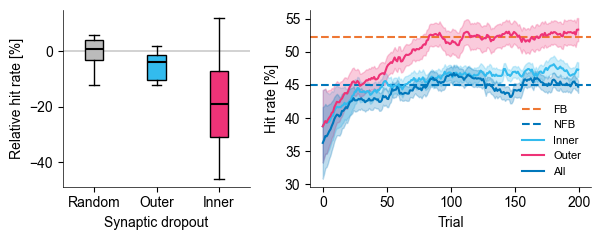

In [24]:

plt.style.use(['nature_d'])

fig, axs = plt.subplot_mosaic([["Dropout", "Freeze"]],width_ratios=[2,3])

axs["Dropout"].axhline(0, color='black', linewidth=0.25)
boxplot_formatted(axs["Dropout"], (data_dropout[:,1:] - data_dropout[:, [0]]) * 100, [GRAY, LIGHT_BLUE, PINK], ["Random", "Outer", "Inner"])
axs["Dropout"].set_xlabel("Synaptic dropout")
axs["Dropout"].set_ylabel("Relative hit rate [%]")

# means from Fig 1 
axs["Freeze"].axhline(0.522500 * 100, color=ORANGE, linewidth=1.5, linestyle='--', label="FB")
axs["Freeze"].axhline(0.449750 * 100, color=DARK_BLUE, linewidth=1.5, linestyle='--', label="NFB")
for i, run in enumerate(RUNS):
    data = RUNS[run]['rolling means']* 100
    color = RUNS[run]['color']
    
    # Plot rolling mean with SEM
    _mean = data.mean(axis=0) 
    sem = data.std(axis=0, ddof=1) / np.sqrt(data.shape[0])
    x = np.arange(len(_mean))
    
    axs["Freeze"].plot(x, _mean, color=color, alpha=1.0, linewidth=1.5, 
                   label=f'{run}')
    if run != "FB":
        axs["Freeze"].fill_between(x, _mean - sem, _mean + sem, color=color, alpha=0.25)
axs["Freeze"].set_xlabel("Trial")
axs["Freeze"].set_ylabel("Hit rate [%]")
axs["Freeze"].legend()
        
# w, h = fig.get_size_inches()
# fig.set_size_inches(w, 3.5)

fig.tight_layout()
if SAVE:
    fig.savefig("fig_2_Dropout_Freeze.pdf", dpi=300)

plt.show()